# Risk Stratified OS Analysis -- Above Threshold Effect

**This notebook analyzes overall survival in patients with advanced urothelial cancer treated with first-line pembrolizumab or carboplatin-based chemotherapy and predicted 6 month survival probability above threshold effect.** 

In [1]:
import numpy as np
import pandas as pd

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

## Import data

In [2]:
treatment_df = pd.read_csv('../outputs/pembro_carbo_index.csv')

In [3]:
treatment_df.sample(3)

,PatientID,LineName,StartDate,avelumab_maintenance
3412,FEC5EFFCE2DBB,carbo,2012-11-06,0
396,F307CDC826A10,pembro,2019-07-15,0
1500,F859FAEF4E024,carbo,2015-07-07,0


In [4]:
treatment_df.shape

(3712, 4)

In [5]:
treatment_df['treatment'] = (treatment_df['LineName'] == 'carbo').astype(int)

In [6]:
dtype_map = pd.read_csv('../outputs/pembro_carbo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembro_carbo_features_df.csv', dtype = dtype_map)

In [7]:
features_df.shape

(3706, 162)

In [8]:
surv_pred_df = pd.read_csv('../outputs/gb_6m_survival_predictions_calibrated.csv')

In [9]:
surv_pred_df.head(3)

,PatientID,psurv_180_calibrated
0,F5AAF96C85477,0.622046
1,F412959B03189,0.622046
2,F6E944C1709E6,0.804389


In [10]:
surv_pred_df.shape

(3138, 2)

In [11]:
df = pd.merge(features_df, treatment_df, on = 'PatientID', how = 'left')

In [12]:
df.shape

(3706, 166)

In [13]:
df = pd.merge(df, surv_pred_df, on = 'PatientID', how = 'left')

In [14]:
df.shape

(3706, 167)

In [15]:
df = df.query('adv_diagnosis_year <= 2021')

In [16]:
df.shape

(3138, 167)

In [17]:
with open('../outputs/crossover_survival_estimate.txt', 'r') as f:
    crossover_survival_estimate = float(f.read())

In [18]:
df = df.query('psurv_180_calibrated >= @crossover_survival_estimate')

In [19]:
df.shape

(2273, 167)

## Survival analysis with IPTW

In [20]:
df.treatment.value_counts()

treatment
1    1504
0     769
Name: count, dtype: int64

In [21]:
# Percent censored
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.361508
1    0.240027
Name: event, dtype: float64

In [22]:
estimator = IPTWSurvivalEstimator()

In [23]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['SmokingStatus', 'PDL1_status'],
              cont_var = ['days_diagnosis_to_adv', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'weight_index', 'percent_change_weight', 'albumin', 'total_bilirubin', 'creatinine', 'van_walraven_score'],
              binary_var = ['sex_male', 'medicaid', 'before_2020', 'days_to_treatment_before_30d', 'GroupStage_mod_na', 'ecog_index_na', 'ses_mod_na', 'Surgery_mod', 'PrimarySite_lower'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False)

In [24]:
iptw_df = estimator.transform()

In [25]:
ps_fig = estimator.propensity_score_plot(bins = 30)

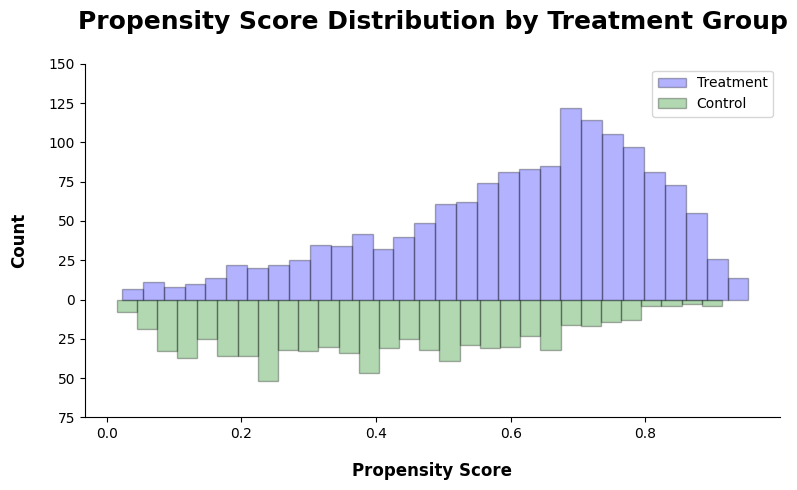

In [26]:
ps_fig

In [27]:
smd_df, smd_fig = estimator.standardized_mean_differences(return_fig = True)

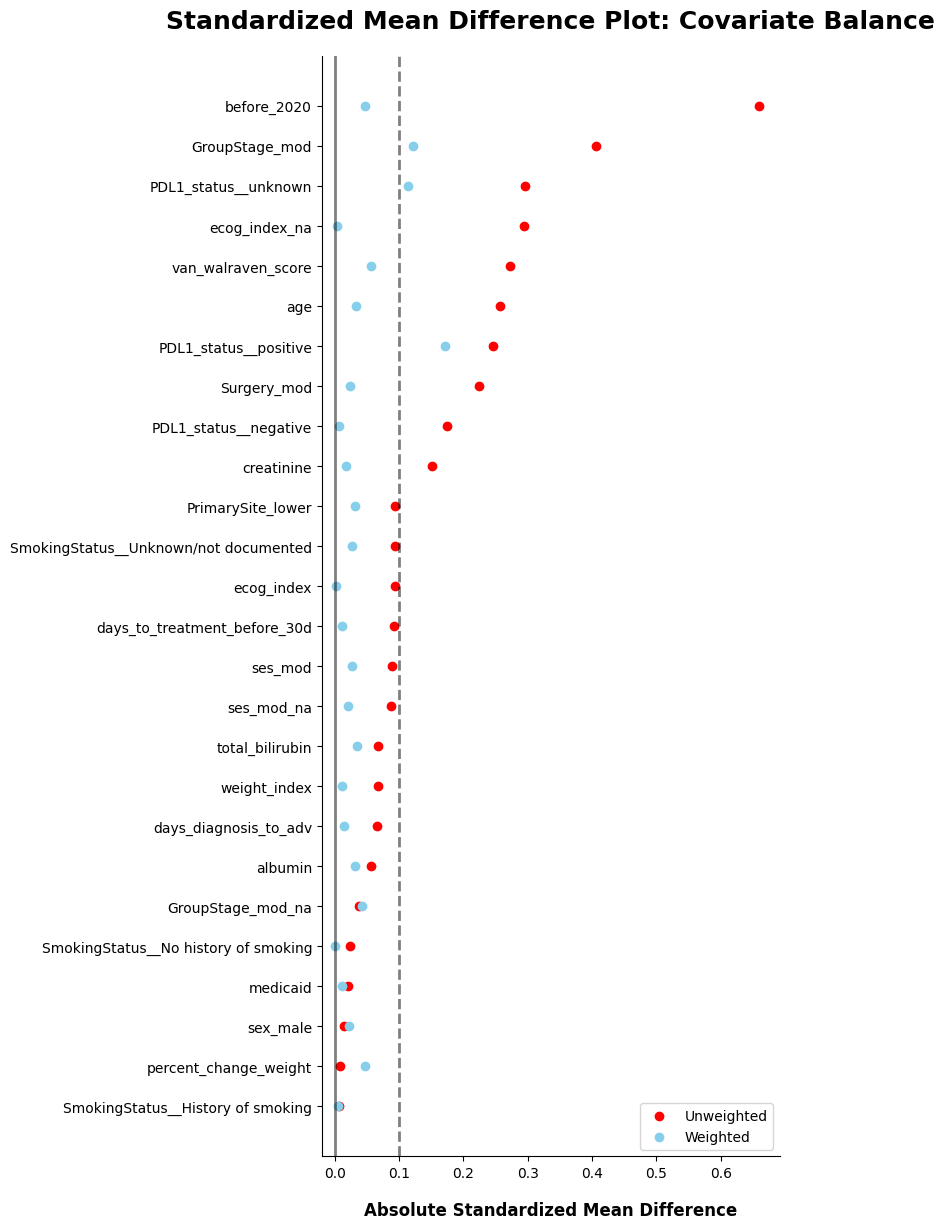

In [28]:
smd_fig

In [29]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42,
                                                               n_jobs = -1)

In [30]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [730, 1095, 1460],
                                     rmst_time_points = [730, 1095, 1460],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42,
                                     n_jobs = -1)

In [31]:
print('Median survival results')
print(f'Carboplatin: {tuple(round(x / 30, 1) for x in results['treatment']['median'])} months')
print(f'Pembrolizumab: {tuple(round(x / 30, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x / 30, 1) for x in results['difference']['median'])} months')

Median survival results
Carboplatin: (15.6, 14.6, 17.4) months
Pembrolizumab: (17.7, 15.0, 20.7) months
Difference: (-2.1, -5.3, 1.1) months


In [35]:
print('RMST results at 2 years')
print(f'Carboplatin: {tuple(round(x, 1) for x in results['treatment']['rmst'][730])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][730])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][730])} days')

print('')
print('RMST results at 3 years')
print(f'Carboplatin: {tuple(round(x, 1) for x in results['treatment']['rmst'][1095])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][1095])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1095])} days')

print('')
print('RMST results at 4 years')
print(f'Carboplatin: {tuple(round(x, 1) for x in results['treatment']['rmst'][1460])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][1460])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1460])} days')

RMST results at 2 years
Carboplatin: (470.5, 452.7, 487.7) days
Pembrolizumab: (456.3, 435.4, 480.5) days
Difference: (14.1, -14.5, 42.0) days

RMST results at 3 years
Carboplatin: (578.6, 550.3, 606.5) days
Pembrolizumab: (592.4, 559.1, 629.6) days
Difference: (-13.8, -61.4, 32.1) days

RMST results at 4 years
Carboplatin: (660.8, 622.3, 698.8) days
Pembrolizumab: (698.6, 653.9, 749.8) days
Difference: (-37.8, -106.5, 24.1) days


In [33]:
print('Probability of survival at 2 years')
print(f'Carboplatin: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][730])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][730])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][730])}')

print('')
print('Probability of survival at 3 years')
print(f'Carboplatin: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1095])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][1095])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1095])}')

print('')
print('Probability of survival at 4 years')
print(f'Carboplatin: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1460])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][1460])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1460])}')

Probability of survival at 2 years
Carboplatin: (0.349, 0.31, 0.385)
Pembrolizumab: (0.42, 0.381, 0.463)
Difference: (-0.071, -0.129, -0.015)

Probability of survival at 3 years
Carboplatin: (0.251, 0.217, 0.286)
Pembrolizumab: (0.316, 0.275, 0.359)
Difference: (-0.065, -0.122, -0.011)

Probability of survival at 4 years
Carboplatin: (0.204, 0.172, 0.234)
Pembrolizumab: (0.274, 0.229, 0.315)
Difference: (-0.071, -0.127, -0.017)


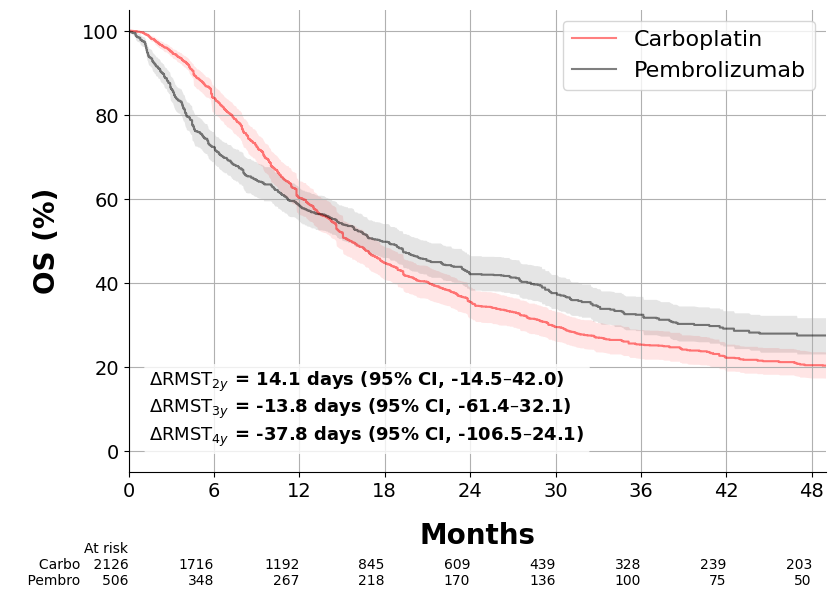

In [39]:
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()

# pembro + chemo estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.treatment_estimate * 100, 
        color='red', 
        alpha=0.5,
        label='Carboplatin')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.treatment_lower_ci * 100, 
                km_confidence_intervals_df.treatment_upper_ci * 100, 
                facecolor='red', 
                alpha=0.1)

# pembro estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.control_estimate * 100, 
        color='black', 
        alpha=0.5,
        label='Pembrolizumab')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.control_lower_ci * 100, 
                km_confidence_intervals_df.control_upper_ci * 100, 
                facecolor='black', 
                alpha=0.1)

tick_months = np.arange(0, 49, 6)   
tick_days = tick_months * 30  
ax.set_xticks(tick_days, labels=[str(m) for m in tick_months])
ax.set_xlim(0, 49 * 30)

ax.set_ylabel('OS (%)', size=20, weight='bold', labelpad=15)
ax.set_xlabel('Months', size=20, weight='bold', labelpad=15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(prop={'size': 16})
ax.grid(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMST differences
rmst_diff_730, rmst_lower_730, rmst_upper_730 = results['difference']['rmst'][730]
rmst_diff_1095, rmst_lower_1095, rmst_upper_1095 = results['difference']['rmst'][1095]
rmst_diff_1460, rmst_lower_1460, rmst_upper_1460 = results['difference']['rmst'][1460]

rmst_text = (
    r'$\Delta \mathrm{RMST}_{2y}$ = '
    f'{rmst_diff_730:.1f} days '
    f'(95% CI, {rmst_lower_730:.1f}–{rmst_upper_730:.1f})'
    '\n'
    r'$\Delta \mathrm{RMST}_{3y}$ = '
    f'{rmst_diff_1095:.1f} days '
    f'(95% CI, {rmst_lower_1095:.1f}–{rmst_upper_1095:.1f})'
    '\n'
    r'$\Delta \mathrm{RMST}_{4y}$ = '
    f'{rmst_diff_1460:.1f} days '
    f'(95% CI, {rmst_lower_1460:.1f}–{rmst_upper_1460:.1f})'
)

add_at_risk_counts(
    estimator.treat_km_, 
    estimator.control_km_, 
    rows_to_show=['At risk'], 
    labels=['Carbo', 'Pembro'],
    xticks=tick_days
)

ax.text(
    0.03, 0.05, rmst_text,
    transform=ax.transAxes,
    fontsize=13,
    fontweight='bold',
    va='bottom',
    bbox=dict(
    boxstyle='round,pad=0.3',
    facecolor='white',
    alpha=0.8,
    edgecolor='none')
)

plt.savefig('../outputs/os_above_crossover.pdf', format='pdf', bbox_inches='tight')